# Business Objective – Home Credit Application Dataset

## Business Objective

Home Credit provides loans to customers who may have limited or no traditional credit history. The main business objective is to analyze loan applicant information and identify meaningful groups of applicants with similar financial, demographic, employment, and credit-related characteristics.

Using clustering techniques, the goal is to discover hidden customer segments without using a predefined target variable.

## Clustering Objectives

1. **Applicant Segmentation**
   - Group loan applicants based on similar financial and demographic characteristics.
   - Identify distinct types of credit applicants.

2. **Income-Based Segmentation**
   - Group applicants based on total income, loan amount, annuity amount, and other financial attributes.
   - Understand differences between low-, medium-, and high-income applicant groups.

3. **Credit Profile Segmentation**
   - Identify applicants with similar credit requirements.
   - Analyze relationships between requested credit amount, income, annuity, and goods price.

4. **Employment Profile Analysis**
   - Segment applicants based on employment-related characteristics.
   - Understand how employment duration, occupation, and income source differ across clusters.

5. **Demographic Segmentation**
   - Identify applicant groups based on age, family size, education, housing type, and other demographic characteristics.

6. **Financial Burden Analysis**
   - Identify groups with different levels of financial burden.
   - Analyze indicators such as:
     - Credit-to-Income Ratio
     - Annuity-to-Income Ratio
     - Credit-to-Goods-Price Ratio

7. **Potential Risk-Pattern Discovery**
   - Discover applicant groups whose characteristics may warrant different levels of credit review.
   - Clustering itself should not be treated as a loan-default prediction model because the test dataset does not contain the target/default label.

8. **Outlier Detection**
   - Identify applicants with unusual income, credit, annuity, employment, or demographic characteristics.
   - Detect applicants significantly different from the majority of customers.

9. **Business Decision Support**
   - Support customer segmentation and portfolio analysis.
   - Help design differentiated loan products and customer communication strategies.
   - Provide additional insights that can complement supervised credit-risk models.

## Machine Learning Objective

Apply unsupervised machine learning algorithms such as:

- K-Means Clustering
- Hierarchical / Agglomerative Clustering
- DBSCAN
- Mean Shift Clustering

Evaluate the quality of the generated clusters using:

- Elbow Method
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Cluster Visualization

## Expected Outcome

The expected outcome is to divide Home Credit loan applicants into meaningful customer segments based on similarities in their financial, demographic, employment, and credit characteristics.

These clusters can then be profiled to understand different types of loan applicants and support portfolio analysis, customer segmentation, credit review, and business strategy.

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
pip install xlrd

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
bank_dataset=pd.read_excel(r'C:\Users\Hp\Downloads\CLUSTERING\data\application_test.xlsx')

In [4]:
from sklearn.cluster import KMeans,AgglomerativeClustering,MeanShift,DBSCAN

In [5]:
bank_dataset.shape

(48744, 123)

In [6]:
bank_dataset=bank_dataset[['AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','CNT_FAM_MEMBERS']]

In [7]:
bank_dataset.shape

(48744, 8)

In [15]:
pip install validclust

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


K-Means Clustering 

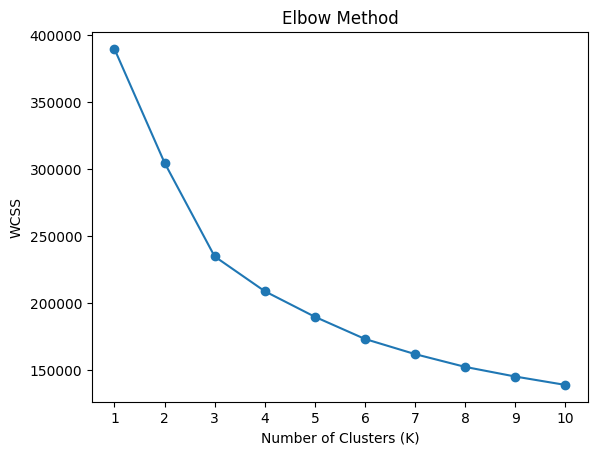

KMeans_Cluster
0    29837
1     9091
2     9816
Name: count, dtype: int64
K-Means Silhouette Score: 0.28306641357058365
K means Dunn Index: 0.01385616225308701


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from validclust import dunn
# Select features
X = bank_dataset[
    [
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        'CNT_FAM_MEMBERS'
    ]
]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS
wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    wcss.append(model.inertia_)

# Elbow Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

# Build K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train and predict clusters
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
bank_dataset['KMeans_Cluster'] = kmeans_labels

# Check number of records in each cluster
print(bank_dataset['KMeans_Cluster'].value_counts().sort_index())

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)

km_distance=pairwise_distances(
    X_scaled[:10000],
    metric='euclidean'
)
km_dunn=dunn(
    km_distance,
    kmeans_labels[:10000]
)
print("K means Dunn Index:",km_dunn)

In [39]:
import pickle
with open("kmeans.pkl","wb") as file:
    pickle.dump(kmeans,file)

Agglomerative Clustering

In [19]:
from sklearn.cluster import AgglomerativeClustering
# Build Agglomerative model
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

# Train and predict clusters
agg_labels = agg_model.fit_predict(X_scaled)
from sklearn.metrics import silhouette_score
agg_score = silhouette_score(
    X_scaled,
    agg_labels,
    metric='euclidean'
)
print("Agglomerative Silhouette Score:", agg_score)
ag_distance=pairwise_distances(
    X_scaled[0:40000],
    metric='euclidean'
)
ag_dunn=dunn(
    ag_distance,
    agg_labels[0:40000]
)
print("Aggloramative Dunn Index:",ag_dunn)

Agglomerative Silhouette Score: 0.2933768896612772
Aggloramative Dunn Index: 0.016695953621838025


In [40]:
import pickle
with open("Agglomarative.pkl","wb") as file:
    pickle.dump(agg_model,file)

DB Scan Clustering

In [20]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
db_labels=db.fit_predict(X_scaled)
print("number of unique clusters", np.unique(db_labels))
print("total number of rows", len(db_labels))
bank_dataset['DBSCAN cluster'] = db_labels
bank_dataset['DBSCAN cluster'].value_counts()
from sklearn.metrics import silhouette_score
db_score = silhouette_score(
    X_scaled,
    db_labels,
    metric='euclidean'
)
print("DBScan Silhouette Score:", db_score)
db_distance=pairwise_distances(
    X_scaled[:30000],
    metric='euclidean'
)
db_dunn=dunn(
    db_distance,
    db_labels[:30000]
)
print("DBScan Dunn Index:",db_dunn)

number of unique clusters [ -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16
  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52
  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70
  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88
  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106
 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124
 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 169 170 171]
total number of rows 48744
DBScan Silhouette Score: -0.31155373591555485
DBScan Dunn Index: 0.00579913346147037


In [41]:
import pickle
with open("DBSCAN.pkl","wb") as file:
    pickle.dump(db,file)

Mean shift Clustering

In [21]:
from sklearn.cluster import MeanShift
ms = MeanShift()
ms_labels=ms.fit_predict(X_scaled)
print("number of unique clusters", np.unique(ms_labels))
print("total number of rows", len(ms_labels))
bank_dataset['MeanShift cluster'] = ms_labels
bank_dataset['MeanShift cluster'].value_counts()
from sklearn.metrics import silhouette_score
ms_score = silhouette_score(
    X_scaled,
    ms_labels,
    metric='euclidean'
)
print("Mean shift Silhouette Score:", ms_score)
ms_distance=pairwise_distances(
    X_scaled[0:25000],
    metric='euclidean'
)
ms_dunn=dunn(
    ms_distance,
    ms_labels[0:25000]
)
print("Mean shift Dunn Index:",db_dunn)

number of unique clusters [0 1 2 3]
total number of rows 48744
Mean shift Silhouette Score: 0.4711051912693084
Mean shift Dunn Index: 0.00579913346147037


In [42]:
import pickle
with open("Mean shift.pkl","wb") as file:
    pickle.dump(ms,file)

k-Modes clustering algorithm

In [22]:
pip install kmodes

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [26]:
bank1_dataset=pd.read_excel(r'C:\Users\Hp\Downloads\CLUSTERING\data\application_test.xlsx')
bank1_dataset.isna().sum()
def fill_null_values(df):
    for column in df.columns:
        if df[column].isna().sum() > 0:

            if df[column].dtype in ['int64', 'float64']:
                df[column] = df[column].fillna(df[column].median())

            else:
                df[column] = df[column].fillna('Unknown')

    return df


bank1_dataset = fill_null_values(bank1_dataset)

print(bank1_dataset.isna().sum())
from kmodes.kmodes import KModes
import numpy as np
bankcat_dataset=bank1_dataset[['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY','NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','OCCUPATION_TYPE','ORGANIZATION_TYPE']]
kmod = KModes(n_clusters=5, init='huang', random_state=42)
kmod_labels = kmod.fit_predict(bankcat_dataset)
print("number of unique clusters", np.unique(kmod_labels))
print("total number of rows", len(kmod_labels))
bank_dataset['KModes cluster'] = kmod_labels
bank_dataset['KModes cluster'].value_counts()
bank1_encoded = pd.get_dummies(
    bankcat_dataset
).astype(int)
kmod_silhouette = silhouette_score(
    bank1_encoded,
    kmod_labels,
    metric='hamming'
)

print("K modes Silhouette Score:", kmod_silhouette)
kmod_distance = pairwise_distances(
    bank1_encoded[1:10000],
    metric='hamming'
)

kmod_dunn = dunn(
    kmod_distance,
    kmod_labels[1:10000]
)

print("Kmodes Dunn Index:", kmod_dunn)

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


SK_ID_CURR                          0
NAME_CONTRACT_TYPE                  0
CODE_GENDER                         0
FLAG_OWN_CAR                        0
FLAG_OWN_REALTY                     0
                                ...  
AMT_REQ_CREDIT_BUREAU_MON           0
AMT_REQ_CREDIT_BUREAU_QRT           0
AMT_REQ_CREDIT_BUREAU_YEAR          0
AMT_REQ_CREDIT_BUREAU_YEAR.1    48744
Unnamed: 122                        0
Length: 123, dtype: int64
number of unique clusters [0 1 2 3 4]
total number of rows 48744
K modes Silhouette Score: 0.16804000009645076
Kmodes Dunn Index: 0.1


In [43]:
import pickle
with open("K Modes.pkl","wb") as file:
    pickle.dump(kmod,file)

K-Prototype Clustering 

In [28]:
bankpro_dataset=[[bank_dataset,bankcat_dataset]]

In [29]:
bankcat_dataset.columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE'],
      dtype='object')

In [30]:
categorical_columns = [
    bankcat_dataset.columns.get_loc(col)
    for col in bankcat_dataset.columns
]

print("Categorical column positions:", categorical_columns)

Categorical column positions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [38]:
from kmodes.kprototypes import KPrototypes
import numpy as np
kp = KPrototypes(
    n_clusters=5,
    init='Huang',
    random_state=42
)
kp_labels=kp.fit_predict(bank_dataset.values,categorical=[0,1,2,3,4,5,6,7,8,9])
print("Unique Clusters:", np.unique(kp_labels))

print("Total Rows:", len(kp_labels))

bank_dataset['KPrototypes cluster'] = kp_labels

print(bank_dataset['KPrototypes cluster'].value_counts())
categorical_names = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE'
]

bankpro_kp_encoded = pd.get_dummies(
    bankcat_dataset,
).astype(float)
kp_silhouette = silhouette_score(
    bankpro_kp_encoded,
    kp_labels,
    metric='euclidean'
)
print("K Prototype silhouette score:",kp_silhouette)
kp_distance = pairwise_distances(
    bankpro_kp_encoded[1:20000],
    metric='euclidean'
)
kp_dunn = dunn(
    kp_distance,
    kp_labels[1:20000]
)
print("K Prototype Dunn Index:", kp_dunn)

Unique Clusters: [0 1 2 3 4]
Total Rows: 48744
KPrototypes cluster
1    13091
0    11873
2    11410
4     9276
3     3094
Name: count, dtype: int64
K Prototype silhouette score: 0.10582446006897729
K Prototype Dunn Index: 0.0


In [45]:
import pickle
with open("K Prototype.pkl","wb") as file:
    pickle.dump(kp,file)